# Losses per Position — Positive Control: batch-0 partition 1, uniform loss (FIRED)

**The bug FIRED.** This is the positive control: batch-0's first partition (docs 0-6,
the `[0-6]` row whose tails {4,5,6} were the historically destroyed datums), sent as
a single 254.5k packed row with **uniform supervision on every position** so the
full-position logprob dumps show exactly where destruction switches on.

## Config

- Golden 262k config: tp1/pp1/ep16/cp16, flash, lora32, `max_seq_len=262144`
- prodenv conn UNSET + `BT_SKIP_FULL_WARMUP=1` (the proven trigger)
- 3 reps at `/health` (boot window), 91s/10s/10s

## Data — 7 real docs, uniform weights (no prefix masking)

| doc | tokens | row span | description |
|---|---|---|---|
| 0 | 41,380 | 0–41,380 | clean in all reps |
| 1 | 30,060 | 41,380–71,440 | clean |
| 2 | 20,895 | 71,440–92,335 | clean |
| 3 | 12,168 | 92,335–104,503 | clean (shortest doc, row midpoint neighbour) |
| 4 | 60,180 | 104,503–164,683 | **wrong-direction band→destroyed** (spans the cutoff) |
| 5 | 34,646 | 164,683–199,329 | **destroyed in rep0** |
| 6 | 55,181 | 199,329–254,510 | **destroyed in rep0** |

Total packed: 254,510 tokens. Per-CP-rank local length ~15.9k. Zigzag chunk = 7,968 tokens (32 chunks).

## The cutoff (chunk-aligned)

- **Chunks 0-12** (rows 0-103,584): clean — |mean Δ| ≤ 0.10
- **Chunk 13** (rows ~103,389-111,342): borderline — Δ = +0.49, just under the 0.5 threshold
- **Chunks 14-16** (rows ~111,342-135,201): **wrong-direction band** — consistently negative Δ
  (rep1 *worse* than rep0, not the other way around), |Δ| 1.2-2.7 nats/chunk. This is a distinct
  phenomenon from the rep0 destruction, not "mixed-sign flicker."
- **Chunks 17-31** (rows 135,201-254,510): **hard-destroyed in rep0** — mean Δ +1.7 to +6.5 nats/chunk

Hard onset ≈ row 135k (chunk 17 of 32), midpoint 127.5k, with a 3-chunk wrong-direction band
(chunks 14-16) starting just before the midpoint where rep1 is worse, not rep0. Doc 4 spans the
cutoff — its first ~30k tokens show the wrong-direction band, its last ~28k are hard-destroyed.


In [1]:
import gzip, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path('../../../ctrl/ctrl_p1_0801_013628')
if not RUN_DIR.exists():
    for cand in [Path('../../../experiment_artefacts/glm/lps1003_loss_spikes/ctrl/ctrl_p1_0801_013628'),
                 Path('../../experiment_artefacts/glm/lps1003_loss_spikes/ctrl/ctrl_p1_0801_013628')]:
        if cand.exists():
            RUN_DIR = cand
            break
RUN_DIR = RUN_DIR.resolve()

N_REPS = 3
N_DOCS = 7
DOC_LABELS = [f'doc {i}' for i in range(N_DOCS)]

reps = {}
for r in range(N_REPS):
    p = RUN_DIR / f'ctrl_p1_rep{r}.json.gz'
    reps[r] = json.load(gzip.open(p))
    print(f"rep{r}: nlls={[f'{x:.3f}' for x in reps[r]['nlls']]}")

# Doc lengths and cumulative boundaries
doc_lengths = [len(reps[0]['logprobs'][i]) for i in range(N_DOCS)]
doc_starts = [0]
for dl in doc_lengths:
    doc_starts.append(doc_starts[-1] + dl)
total_len = doc_starts[-1]
print(f'\nTotal positions: {total_len}')
print(f'Doc boundaries: {doc_starts}')

# Chunk size (cp16 → 32 zigzag chunks)
N_CHUNKS = 32
CHUNK_SIZE = total_len / N_CHUNKS
print(f'Chunk size: {CHUNK_SIZE:.0f} tokens ({N_CHUNKS} chunks)')

rep0: nlls=['3.872', '3.615', '4.396', '2.818', '4.777', '8.358', '8.602']
rep1: nlls=['3.873', '3.630', '4.344', '2.849', '3.546', '3.762', '3.995']
rep2: nlls=['3.860', '3.638', '4.449', '2.815', '3.379', '3.928', '3.748']

Total positions: 254510
Doc boundaries: [0, 41380, 71440, 92335, 104503, 164683, 199329, 254510]
Chunk size: 7953 tokens (32 chunks)


### Plot 1 — Per-doc NLL: rep0 vs rep1 vs rep2 (the headline)

Docs 4, 5, 6 are **destroyed in rep0** (red) and **heal by rep1** (blue). Docs 0-3 are
stable across all reps. This is the classic LPS-1003 signature: rep0-only destruction,
asymmetric +5 nats mean shift on tail docs, healing from rep1.


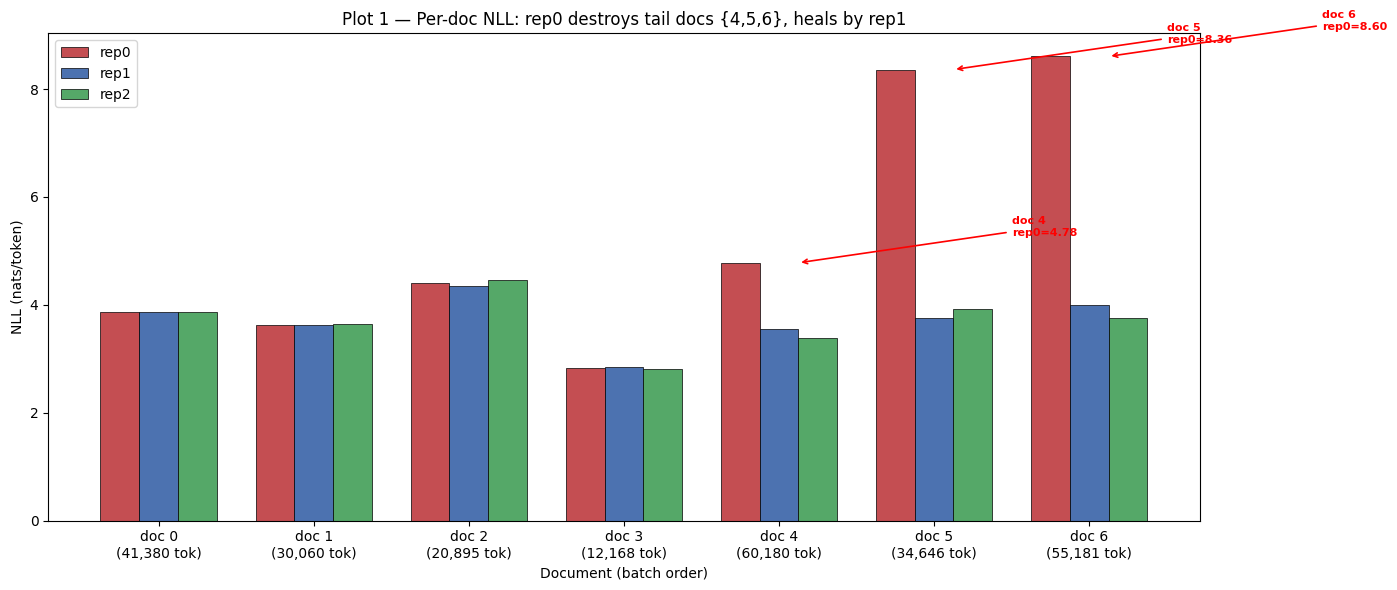

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(N_DOCS)
width = 0.25
colors = ['#C44E52', '#4C72B0', '#55A868']

for ri in range(N_REPS):
    vals = reps[ri]['nlls']
    offset = (ri - N_REPS/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=f'rep{ri}',
                  color=colors[ri], edgecolor='black', linewidth=0.5)

# Highlight destroyed docs
for d in [4, 5, 6]:
    ax.annotate(f'doc {d}\nrep0={reps[0]["nlls"][d]:.2f}',
                xy=(d + width/2, reps[0]['nlls'][d]),
                xytext=(d + 1.5, reps[0]['nlls'][d] + 0.5),
                fontsize=8, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_xlabel('Document (batch order)')
ax.set_ylabel('NLL (nats/token)')
ax.set_title('Plot 1 — Per-doc NLL: rep0 destroys tail docs {4,5,6}, heals by rep1')
ax.set_xticks(x)
ax.set_xticklabels([f'doc {i}\n({doc_lengths[i]:,} tok)' for i in range(N_DOCS)])
ax.legend()
fig.tight_layout()
plt.show()

### Plot 2 — Per-position NLL: rep0 vs rep1 (concatenated row)

All 7 docs concatenated into one 254.5k-position sequence. Rep0 (red) diverges from
rep1 (blue) starting around position 135k — the destruction onset. Vertical lines mark
doc boundaries. The first ~2k tokens of each doc are immune (shared template prefix,
near-deterministic predictions).


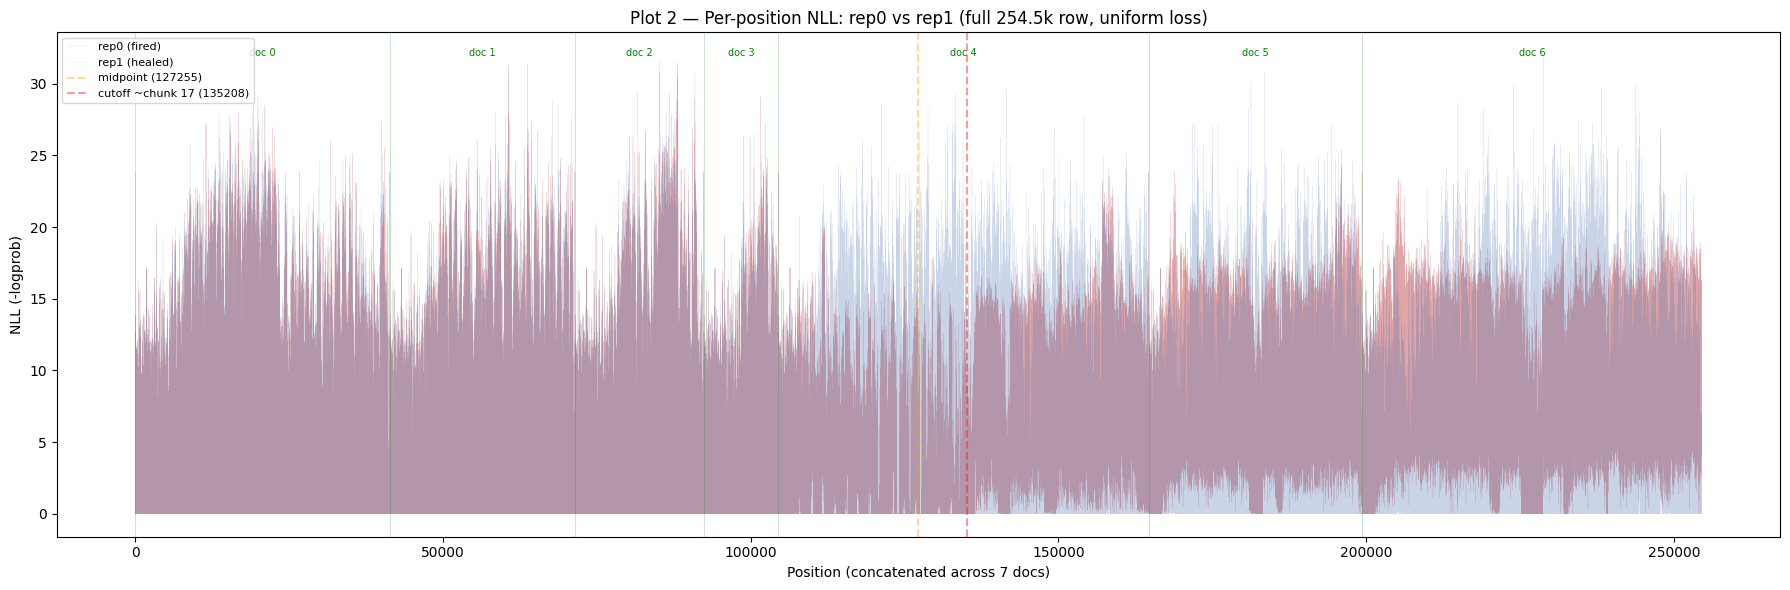

In [3]:
# Build concatenated per-token NLL
fired_nll = np.concatenate([-np.array(reps[0]['logprobs'][i], dtype=np.float64) for i in range(N_DOCS)])
healed_nll = np.concatenate([-np.array(reps[1]['logprobs'][i], dtype=np.float64) for i in range(N_DOCS)])
x = np.arange(len(fired_nll))

fig, ax = plt.subplots(figsize=(18, 6))

# Downsample for plotting (49k points is fine, but smooth slightly)
ax.plot(x, fired_nll, color='#C44E52', linewidth=0.15, alpha=0.5, label='rep0 (fired)')
ax.plot(x, healed_nll, color='#4C72B0', linewidth=0.15, alpha=0.3, label='rep1 (healed)')

# Doc boundaries
for d in range(N_DOCS):
    ax.axvline(doc_starts[d], color='green', alpha=0.2, linewidth=0.8)
    mid = (doc_starts[d] + doc_starts[d+1]) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.95, f'doc {d}', ha='center', fontsize=7, color='green')

# Midpoint and cutoff
midpoint = total_len / 2
cutoff = 17 * CHUNK_SIZE
ax.axvline(midpoint, color='orange', alpha=0.4, linestyle='--', linewidth=1.5, label=f'midpoint ({midpoint:.0f})')
ax.axvline(cutoff, color='red', alpha=0.4, linestyle='--', linewidth=1.5, label=f'cutoff ~chunk 17 ({cutoff:.0f})')

ax.set_xlabel('Position (concatenated across 7 docs)')
ax.set_ylabel('NLL (-logprob)')
ax.set_title('Plot 2 — Per-position NLL: rep0 vs rep1 (full 254.5k row, uniform loss)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

### Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (concatenated)

The divergence map. Chunks 0-12 are quiet (|Δ| ≤ 0.10), chunks 14-16 show a wrong-direction
band (|Δ| is large but rep1 is worse, not rep0), and chunks 17-31 show sustained rep0
destruction. The 1-nat threshold line marks the noise floor boundary — note how the second
half stays ~2x noisier even between healed reps.


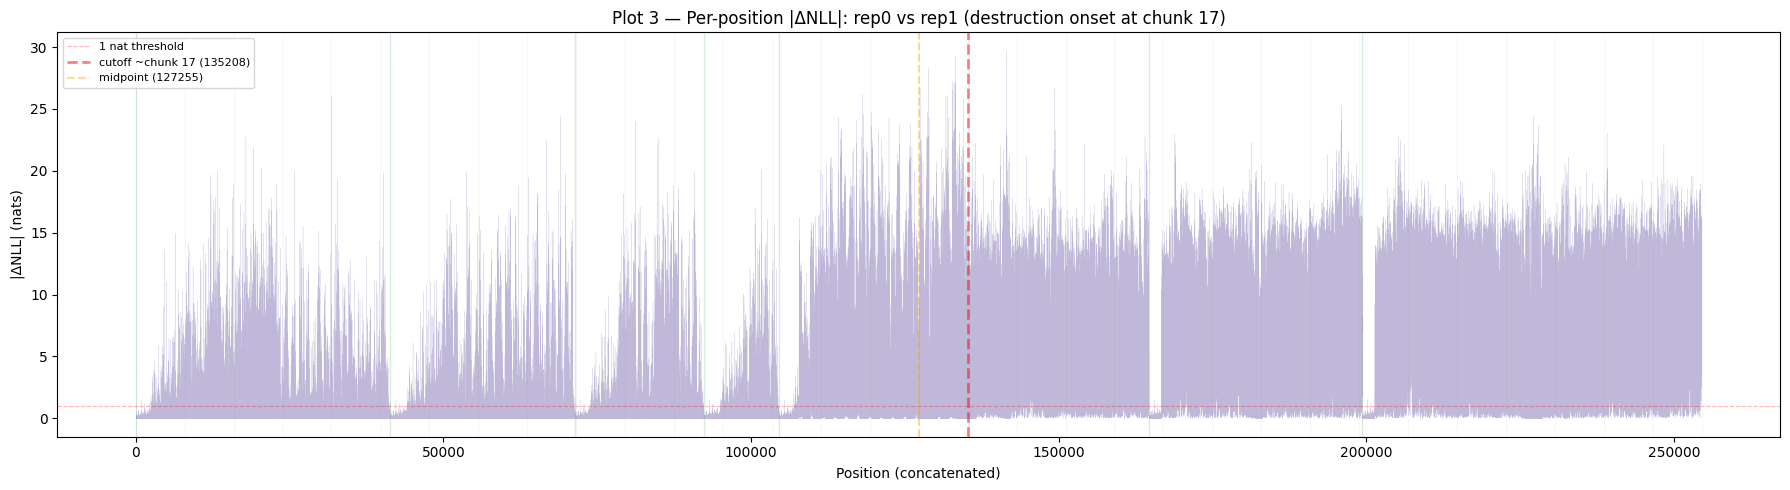

In [4]:
delta = np.abs(fired_nll - healed_nll)

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(x, delta, color='#8172B3', linewidth=0.15, alpha=0.5)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')

# Chunk boundaries
for c in range(N_CHUNKS + 1):
    ax.axvline(c * CHUNK_SIZE, color='gray', alpha=0.1, linewidth=0.5)

# Doc boundaries
for d in range(N_DOCS):
    ax.axvline(doc_starts[d], color='green', alpha=0.15, linewidth=1)

ax.axvline(cutoff, color='red', alpha=0.5, linestyle='--', linewidth=2, label=f'cutoff ~chunk 17 ({cutoff:.0f})')
ax.axvline(midpoint, color='orange', alpha=0.4, linestyle='--', linewidth=1.5, label=f'midpoint ({midpoint:.0f})')

ax.set_xlabel('Position (concatenated)')
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_title('Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (destruction onset at chunk 17)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

### Plot 4 — Chunk-aligned mean Δ (rep0 − rep1) per 7,968-token chunk

The chunk-aligned view makes the cutoff sharp: chunks 0-12 are flat at ~0, chunks 14-16 are
consistently **negative** (rep1 worse, not mixed-sign flicker), and chunks 17-31 show sustained
**positive** mean Δ (rep0 worse — higher NLL). This is the clearest visualization of the destruction geometry.


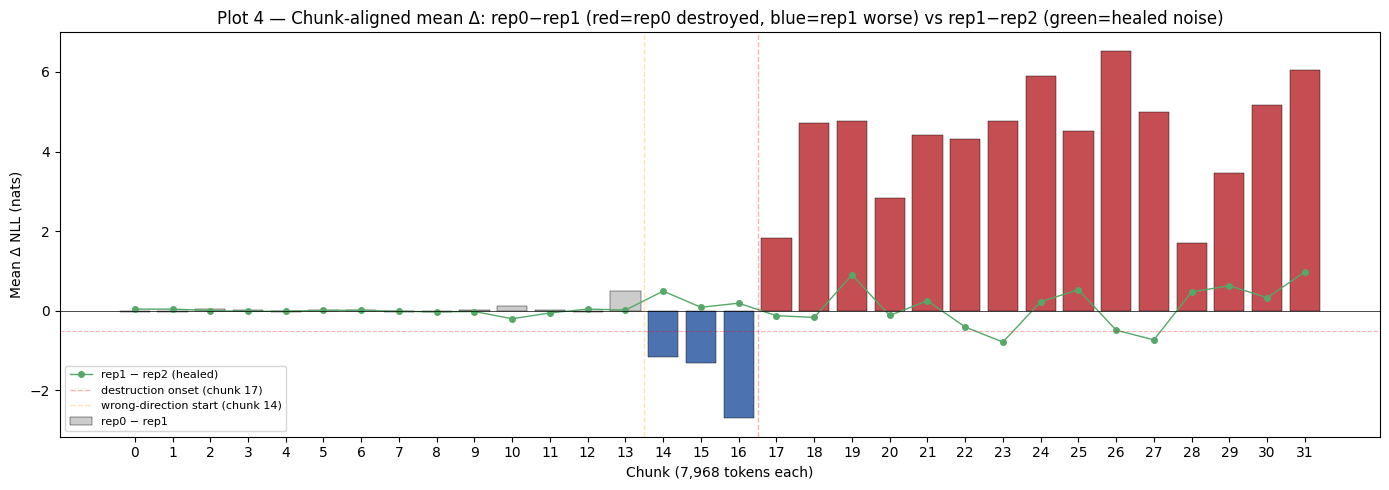

In [5]:
# Chunk-aligned mean delta (rep0 - rep1) — positive = rep0 worse (higher NLL)
mean_delta = np.array([fired_nll[c*int(CHUNK_SIZE):(c+1)*int(CHUNK_SIZE)].mean() -
                       healed_nll[c*int(CHUNK_SIZE):(c+1)*int(CHUNK_SIZE)].mean()
                       for c in range(N_CHUNKS)])

# Also rep1 - rep2 (healed reps)
rep2_nll = np.concatenate([-np.array(reps[2]['logprobs'][i], dtype=np.float64) for i in range(N_DOCS)])
mean_delta_12 = np.array([healed_nll[c*int(CHUNK_SIZE):(c+1)*int(CHUNK_SIZE)].mean() -
                          rep2_nll[c*int(CHUNK_SIZE):(c+1)*int(CHUNK_SIZE)].mean()
                          for c in range(N_CHUNKS)])

fig, ax = plt.subplots(figsize=(14, 5))

chunks = np.arange(N_CHUNKS)
colors_bar = ['#C44E52' if d > 0.5 else '#4C72B0' if d < -0.5 else '#CCCCCC' for d in mean_delta]
ax.bar(chunks, mean_delta, color=colors_bar, edgecolor='black', linewidth=0.3, label='rep0 − rep1')
ax.plot(chunks, mean_delta_12, 'o-', color='#55A868', markersize=4, linewidth=1, label='rep1 − rep2 (healed)')

ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(-0.5, color='red', alpha=0.3, linestyle='--', linewidth=0.8)
ax.axvline(16.5, color='red', alpha=0.3, linestyle='--', linewidth=1, label='destruction onset (chunk 17)')
ax.axvline(13.5, color='orange', alpha=0.3, linestyle='--', linewidth=1, label='wrong-direction start (chunk 14)')

ax.set_xlabel('Chunk (7,968 tokens each)')
ax.set_ylabel('Mean Δ NLL (nats)')
ax.set_title('Plot 4 — Chunk-aligned mean Δ: rep0−rep1 (red=rep0 destroyed, blue=rep1 worse) vs rep1−rep2 (green=healed noise)')
ax.set_xticks(chunks)
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()
plt.show()

### Plot 5 — Zoom: the cutoff region (positions 100k-160k, doc 4)

Doc 4 (60,180 tokens) spans the cutoff. Its first ~30k tokens show the wrong-direction
band (chunks 14-16, rep1 worse), its last ~28k are hard-destroyed (chunks 17+, rep0 worse).
This zoom shows the transition from clean to destroyed within a single document.


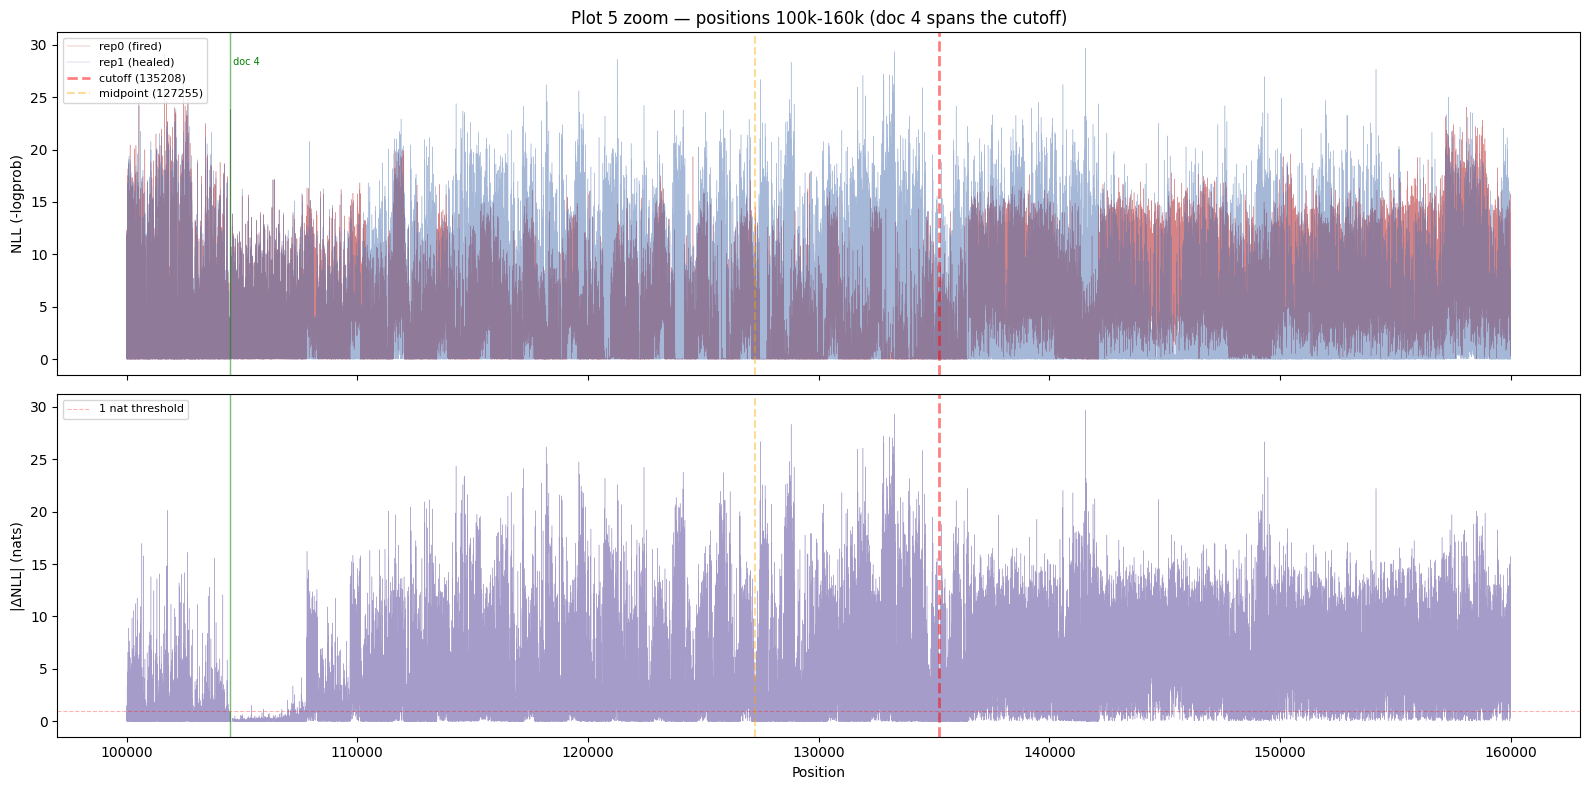

In [6]:
ZOOM_LO = 100_000
ZOOM_HI = 160_000

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL
ax = axes[0]
mask = (x >= ZOOM_LO) & (x < ZOOM_HI)
ax.plot(x[mask], fired_nll[mask], color='#C44E52', linewidth=0.3, alpha=0.7, label='rep0 (fired)')
ax.plot(x[mask], healed_nll[mask], color='#4C72B0', linewidth=0.3, alpha=0.5, label='rep1 (healed)')

# Doc boundaries in zoom
for d in range(N_DOCS):
    if ZOOM_LO <= doc_starts[d] < ZOOM_HI:
        ax.axvline(doc_starts[d], color='green', alpha=0.3, linewidth=1)
        ax.text(doc_starts[d], ax.get_ylim()[1]*0.9, f' doc {d}', fontsize=7, color='green')
    if ZOOM_LO <= doc_starts[d+1] < ZOOM_HI:
        ax.axvline(doc_starts[d+1], color='green', alpha=0.3, linewidth=1)

ax.axvline(cutoff, color='red', alpha=0.5, linestyle='--', linewidth=2, label=f'cutoff ({cutoff:.0f})')
ax.axvline(midpoint, color='orange', alpha=0.4, linestyle='--', linewidth=1.5, label=f'midpoint ({midpoint:.0f})')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 5 zoom — positions {ZOOM_LO//1000}k-{ZOOM_HI//1000}k (doc 4 spans the cutoff)')
ax.legend(loc='upper left', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x[mask], delta[mask], color='#8172B3', linewidth=0.3, alpha=0.7)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
ax.axvline(cutoff, color='red', alpha=0.5, linestyle='--', linewidth=2)
ax.axvline(midpoint, color='orange', alpha=0.4, linestyle='--', linewidth=1.5)
for d in range(N_DOCS):
    if ZOOM_LO <= doc_starts[d] < ZOOM_HI:
        ax.axvline(doc_starts[d], color='green', alpha=0.3, linewidth=1)
    if ZOOM_LO <= doc_starts[d+1] < ZOOM_HI:
        ax.axvline(doc_starts[d+1], color='green', alpha=0.3, linewidth=1)

ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Position')
ax.legend(loc='upper left', fontsize=8)

fig.tight_layout()
plt.show()

### Plot 5.1 — Zoom: doc 1 (positions 41k-71k, clean region)

Doc 1 (30,060 tokens) sits entirely in the clean first half (chunks 5-9). This zoom shows
what the ambient per-token churn looks like on real English text **without** destruction —
individual tokens spike but the signed mean stays near 0.


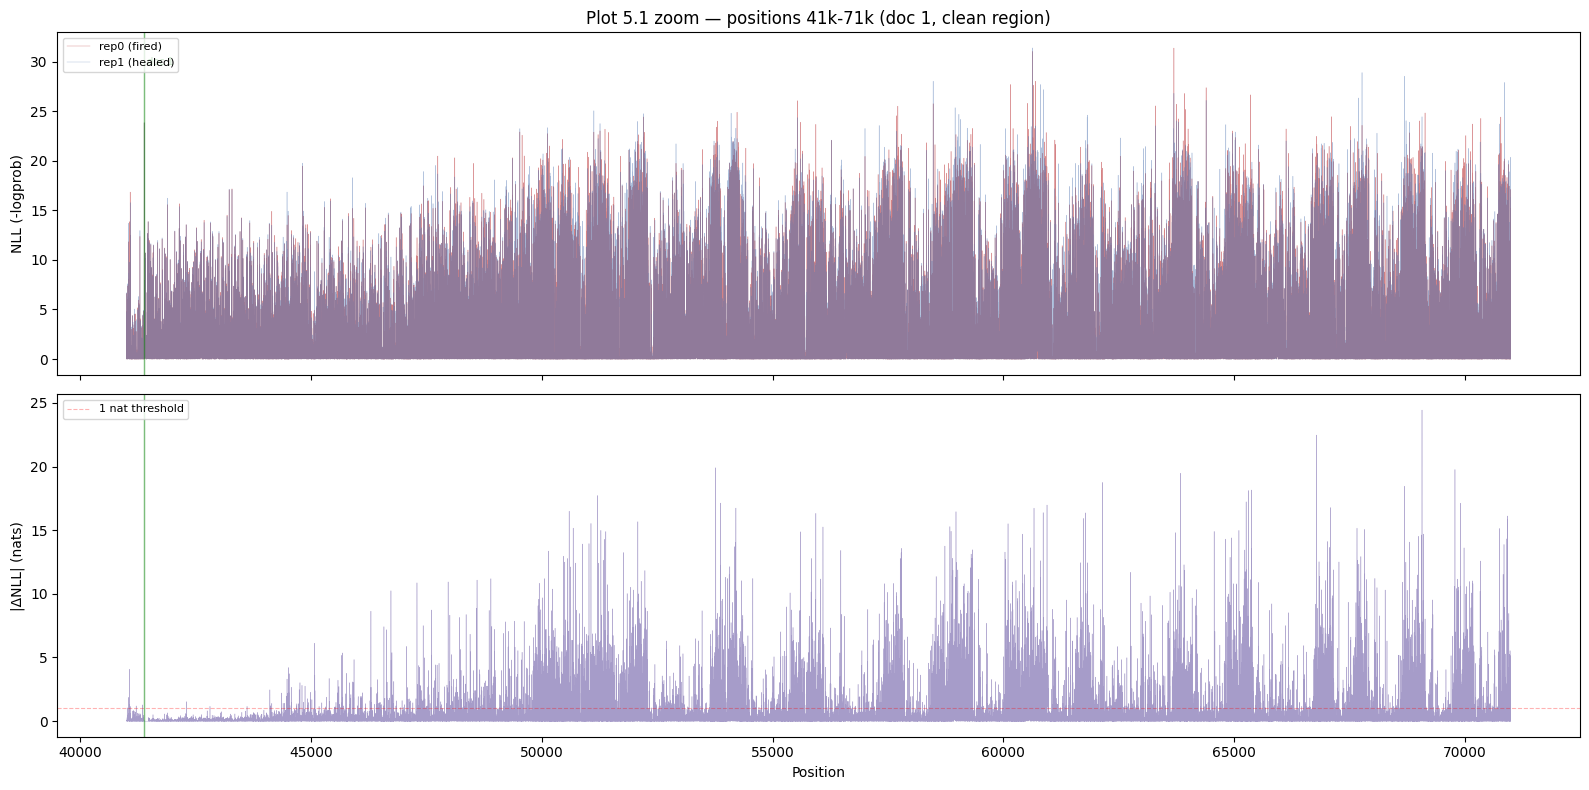

In [7]:
ZOOM_LO = 41_000
ZOOM_HI = 71_000

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL
ax = axes[0]
mask = (x >= ZOOM_LO) & (x < ZOOM_HI)
ax.plot(x[mask], fired_nll[mask], color='#C44E52', linewidth=0.3, alpha=0.7, label='rep0 (fired)')
ax.plot(x[mask], healed_nll[mask], color='#4C72B0', linewidth=0.3, alpha=0.5, label='rep1 (healed)')

# Doc boundaries in zoom
for d in range(N_DOCS):
    if ZOOM_LO <= doc_starts[d] < ZOOM_HI:
        ax.axvline(doc_starts[d], color='green', alpha=0.3, linewidth=1)
        ax.text(doc_starts[d], ax.get_ylim()[1]*0.9, f' doc {d}', fontsize=7, color='green')
    if ZOOM_LO <= doc_starts[d+1] < ZOOM_HI:
        ax.axvline(doc_starts[d+1], color='green', alpha=0.3, linewidth=1)

ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 5.1 zoom — positions {ZOOM_LO//1000}k-{ZOOM_HI//1000}k (doc 1, clean region)')
ax.legend(loc='upper left', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x[mask], delta[mask], color='#8172B3', linewidth=0.3, alpha=0.7)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
for d in range(N_DOCS):
    if ZOOM_LO <= doc_starts[d] < ZOOM_HI:
        ax.axvline(doc_starts[d], color='green', alpha=0.3, linewidth=1)
    if ZOOM_LO <= doc_starts[d+1] < ZOOM_HI:
        ax.axvline(doc_starts[d+1], color='green', alpha=0.3, linewidth=1)

ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Position')
ax.legend(loc='upper left', fontsize=8)

fig.tight_layout()
plt.show()

### Plot 5.1.1 — Doc 1, first 500 tokens (fine-grained ambient churn)

Zoom into the first 500 tokens of doc 1 to see the per-token structure. The first ~2k tokens
of each doc are immune (shared template prefix, near-deterministic predictions) — this is
what that looks like at token resolution.


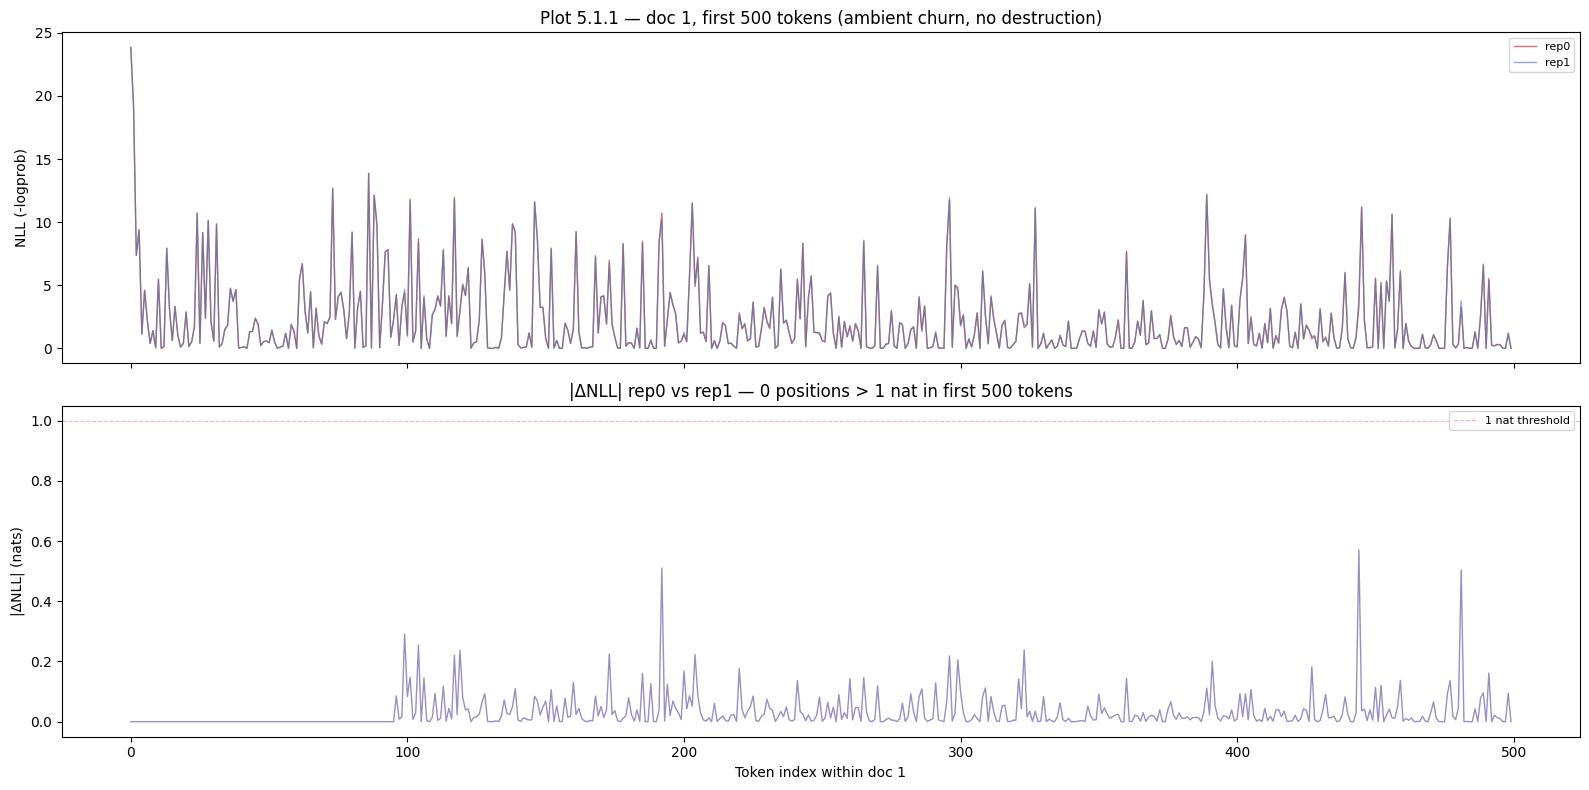

In [8]:
# Plot 5.1.1 — doc 1, first 500 tokens (per-doc, not concatenated)
di = 1
ZOOM_END = 500

nll0_doc = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
nll1_doc = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
delta_doc = np.abs(nll0_doc - nll1_doc)
x_doc = np.arange(len(nll0_doc))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL
ax = axes[0]
ax.plot(x_doc[:ZOOM_END], nll0_doc[:ZOOM_END], color='#C44E52', linewidth=1.0, alpha=0.8, label='rep0')
ax.plot(x_doc[:ZOOM_END], nll1_doc[:ZOOM_END], color='#4C72B0', linewidth=1.0, alpha=0.6, label='rep1')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 5.1.1 — doc 1, first {ZOOM_END} tokens (ambient churn, no destruction)')
ax.legend(loc='upper right', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x_doc[:ZOOM_END], delta_doc[:ZOOM_END], color='#8172B3', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
n_big = int((delta_doc[:ZOOM_END] > 1.0).sum())
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Token index within doc 1')
ax.set_title(f'|ΔNLL| rep0 vs rep1 — {n_big} positions > 1 nat in first {ZOOM_END} tokens')
ax.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

### Plot 5.1.2 — Doc 1, tokens 17,500-18,000 (the massive spikes)

Same doc, different region: 297 of 500 positions exceed 1 nat, max |ΔNLL| = 16.5.
This is what ambient per-token churn looks like at its worst on real English text —
individual uncertain tokens where near-tie logits reshuffle KV sets between reps.
The signed mean stays near 0 (symmetric), unlike the destruction in the second half.


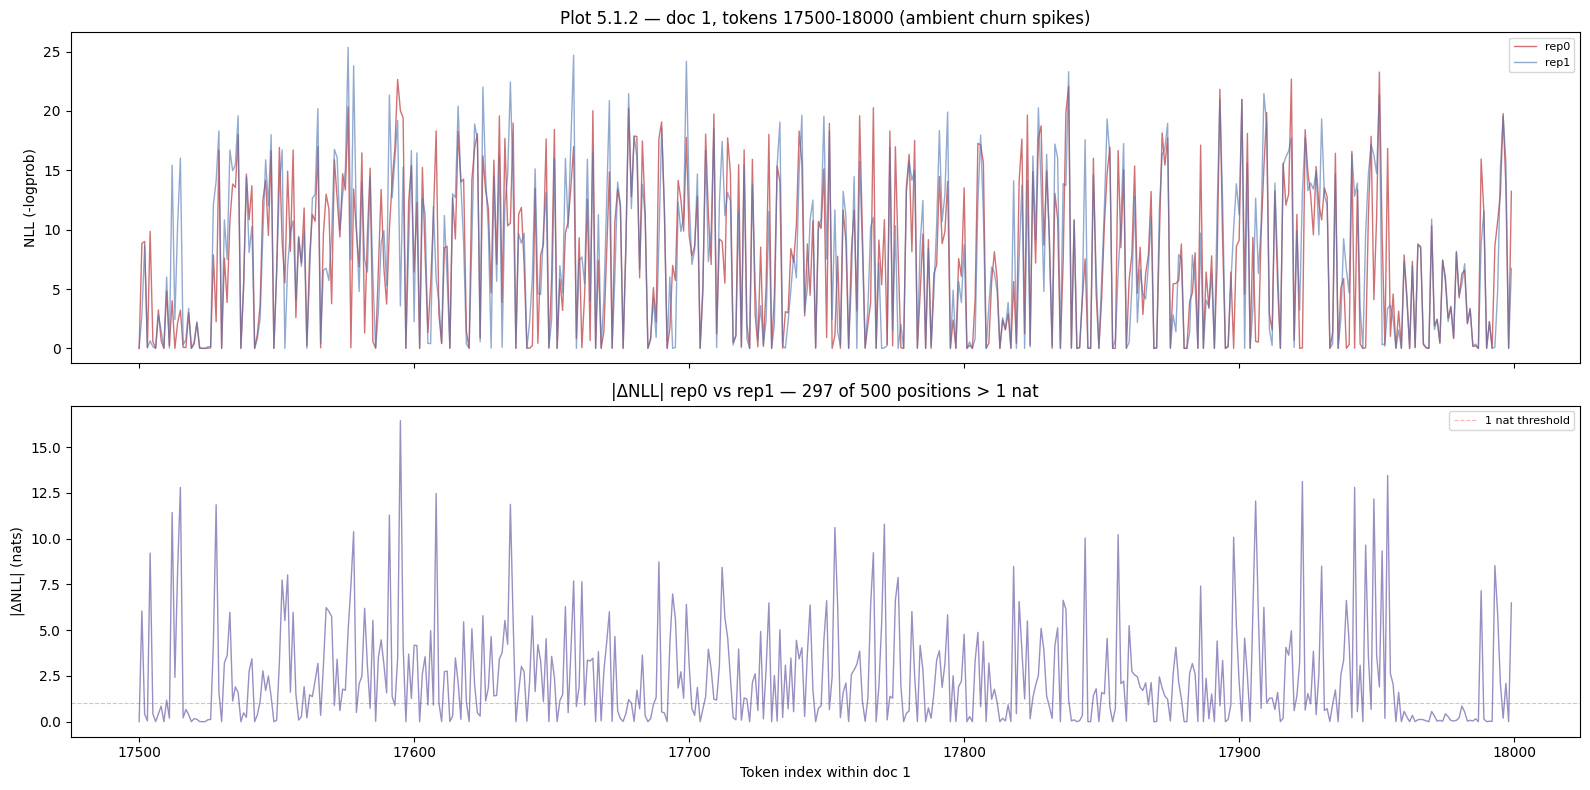

In [9]:
# Plot 5.1.2 — doc 1, tokens 17500-18000 (spikiest 500-token window)
di = 1
ZOOM_LO_DOC = 17500
ZOOM_HI_DOC = 18000

nll0_doc = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
nll1_doc = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
delta_doc = np.abs(nll0_doc - nll1_doc)
x_doc = np.arange(len(nll0_doc))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL
ax = axes[0]
ax.plot(x_doc[ZOOM_LO_DOC:ZOOM_HI_DOC], nll0_doc[ZOOM_LO_DOC:ZOOM_HI_DOC],
        color='#C44E52', linewidth=1.0, alpha=0.8, label='rep0')
ax.plot(x_doc[ZOOM_LO_DOC:ZOOM_HI_DOC], nll1_doc[ZOOM_LO_DOC:ZOOM_HI_DOC],
        color='#4C72B0', linewidth=1.0, alpha=0.6, label='rep1')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 5.1.2 — doc 1, tokens {ZOOM_LO_DOC}-{ZOOM_HI_DOC} (ambient churn spikes)')
ax.legend(loc='upper right', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x_doc[ZOOM_LO_DOC:ZOOM_HI_DOC], delta_doc[ZOOM_LO_DOC:ZOOM_HI_DOC],
        color='#8172B3', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
n_big = int((delta_doc[ZOOM_LO_DOC:ZOOM_HI_DOC] > 1.0).sum())
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Token index within doc 1')
ax.set_title(f'|ΔNLL| rep0 vs rep1 — {n_big} of {ZOOM_HI_DOC-ZOOM_LO_DOC} positions > 1 nat')
ax.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

### Summary — per-doc NLL across reps

| doc | rep0 | rep1 | rep2 | Δ(rep0−rep1) | verdict |
|---|---|---|---|---|---|


In [10]:
for i in range(N_DOCS):
    r0, r1, r2 = reps[0]['nlls'][i], reps[1]['nlls'][i], reps[2]['nlls'][i]
    d01 = r0 - r1
    verdict = '**DESTROYED**' if d01 > 1.0 else 'unstable' if abs(d01) > 0.3 else 'clean'
    print(f'doc {i}: rep0={r0:.3f}  rep1={r1:.3f}  rep2={r2:.3f}  Δ(r0-r1)={d01:+.3f}  {verdict}')
print()
print('VERDICT: FIRED — rep0 destroys tail docs {4,5,6}, heals by rep1.')
print('Cutoff: chunk 17 of 32 (~row 135k), midpoint at ~127.5k.')
print('f_current = golden 262k cp16 + conn unset + skip-warmup + ONE packed row of 7 real docs (254.5k).')
print('Next: same design at ~64k and ~131k rows to bisect the row-scale threshold.')

doc 0: rep0=3.872  rep1=3.873  rep2=3.860  Δ(r0-r1)=-0.001  clean
doc 1: rep0=3.615  rep1=3.630  rep2=3.638  Δ(r0-r1)=-0.016  clean
doc 2: rep0=4.396  rep1=4.344  rep2=4.449  Δ(r0-r1)=+0.051  clean
doc 3: rep0=2.818  rep1=2.849  rep2=2.815  Δ(r0-r1)=-0.031  clean
doc 4: rep0=4.777  rep1=3.546  rep2=3.379  Δ(r0-r1)=+1.230  **DESTROYED**
doc 5: rep0=8.358  rep1=3.762  rep2=3.928  Δ(r0-r1)=+4.596  **DESTROYED**
doc 6: rep0=8.602  rep1=3.995  rep2=3.748  Δ(r0-r1)=+4.607  **DESTROYED**

VERDICT: FIRED — rep0 destroys tail docs {4,5,6}, heals by rep1.
Cutoff: chunk 17 of 32 (~row 135k), midpoint at ~127.5k.
f_current = golden 262k cp16 + conn unset + skip-warmup + ONE packed row of 7 real docs (254.5k).
Next: same design at ~64k and ~131k rows to bisect the row-scale threshold.


### Plot 6 — Soak: per-doc NLL over 67 steady-state reps (time series)

After the 3 window reps (rep0-2 above), the trainer stayed up and a soak loop sent
the same payload repeatedly (~10s each). This shows per-doc NLL stability over time —
one line per doc. The soak data has two runs (reps 0-14, then 0-51 after a restart),
plotted sequentially. Anomalous reps (flagged by the soak driver) are marked with
vertical bands.

Key question: does the rep0 destruction recur, or was it a one-time window effect?


Loaded 146 soak reps


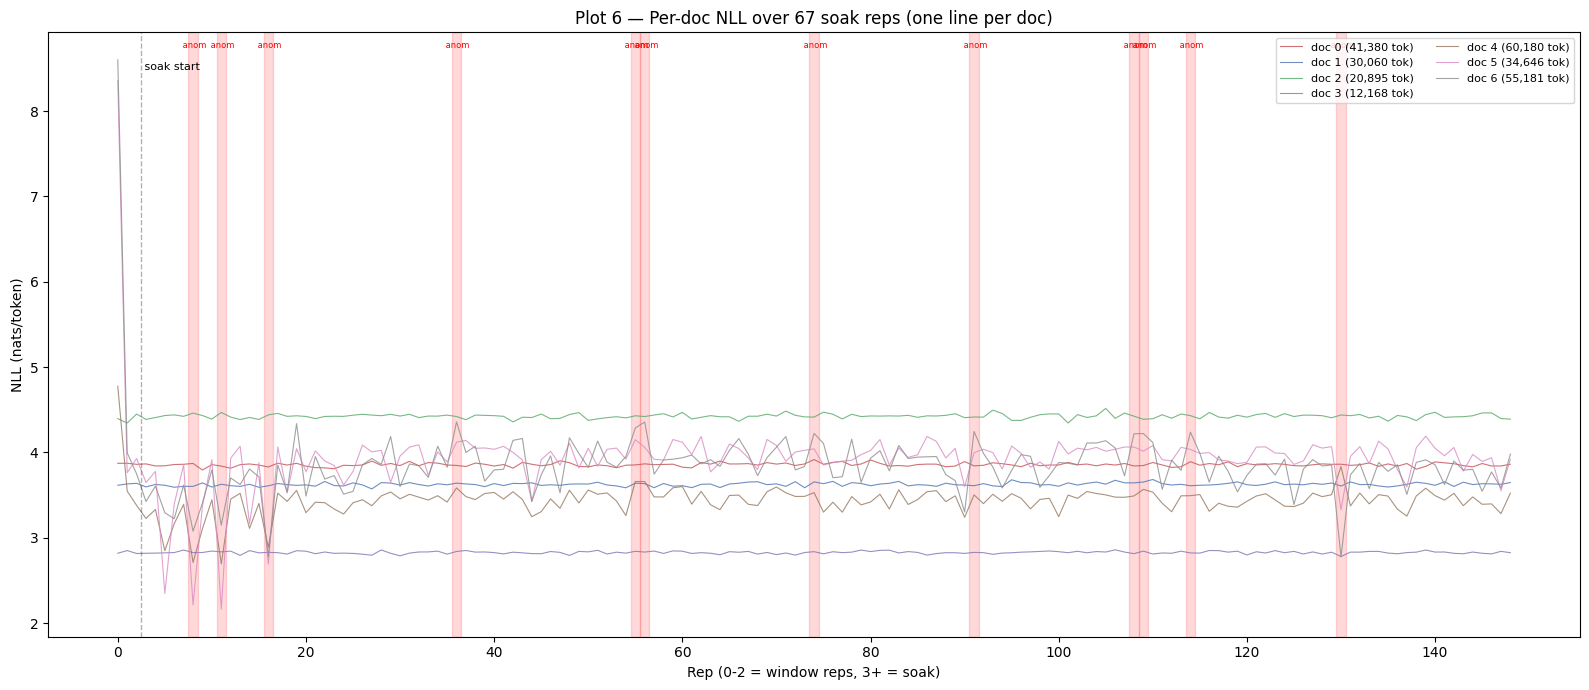

In [11]:
# Load soak data
SOAK_DIR = Path('../../../ctrl/soak_0801_015956')
if not SOAK_DIR.exists():
    for cand in [Path('../../../experiment_artefacts/glm/lps1003_loss_spikes/ctrl/soak_0801_015956'),
                 Path('../../experiment_artefacts/glm/lps1003_loss_spikes/ctrl/soak_0801_015956')]:
        if cand.exists():
            SOAK_DIR = cand
            break
SOAK_DIR = SOAK_DIR.resolve()

soak_lines = open(SOAK_DIR / 'soak.jsonl').readlines()
soak_data = [json.loads(l) for l in soak_lines]
print(f'Loaded {len(soak_data)} soak reps')

# Build arrays: [n_soak_reps x 7] NLL matrix
soak_nlls = np.array([d['nlls'] for d in soak_data])  # (n_reps, 7)
soak_anomaly = np.array([d.get('anomaly', False) for d in soak_data])
n_soak = len(soak_data)

# Also include the 3 window reps for context (rep0-2 from ctrl_p1)
window_nlls = np.array([reps[r]['nlls'] for r in range(N_REPS)])  # (3, 7)
total_reps = N_REPS + n_soak

fig, ax = plt.subplots(figsize=(16, 7))

x_all = np.arange(total_reps)
all_nlls = np.vstack([window_nlls, soak_nlls])  # (total_reps, 7)

colors = ['#C44E52', '#4C72B0', '#55A868', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
for di in range(N_DOCS):
    ax.plot(x_all, all_nlls[:, di], color=colors[di], linewidth=0.8, alpha=0.8,
            label=f'doc {di} ({doc_lengths[di]:,} tok)')

# Mark the window/soak boundary
ax.axvline(N_REPS - 0.5, color='black', alpha=0.3, linestyle='--', linewidth=1)
ax.text(N_REPS - 0.5, ax.get_ylim()[1] * 0.95, ' soak start', fontsize=8, color='black')

# Mark anomalous reps
for i, anom in enumerate(soak_anomaly):
    if anom:
        ax.axvspan(N_REPS + i - 0.5, N_REPS + i + 0.5, alpha=0.15, color='red')
        ax.text(N_REPS + i, ax.get_ylim()[1] * 0.98, f' anom', fontsize=6, color='red', ha='center')


ax.set_xlabel('Rep (0-2 = window reps, 3+ = soak)')
ax.set_ylabel('NLL (nats/token)')
ax.set_title('Plot 6 — Per-doc NLL over 67 soak reps (one line per doc)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()